# 🤖 Machine Learning — Partie 2
## Modèles avancés et optimisation

---

### 📋 Sommaire
1. 📦 Imports
2. 🗂️ Préparation des données
3. ⚙️ Méthodes d'optimisation
4. 🔵 Modèles Non Supervisés
5. 📋 Conclusion


## 📦 1. Imports


Je regroupe tous mes imports dans une seule cellule.


In [1]:
import numpy as np                                          # calcul numérique
import pandas as pd                                          # manipulation des données
import matplotlib.pyplot as plt                              # graphiques
import warnings
warnings.filterwarnings('ignore')

# ── Préparation des données ───────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder  # normalisation et encodage
from sklearn.pipeline import Pipeline                                           # enchaîner les étapes

# ── Modèles supervisés ───────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression                            # régression logistique
from sklearn.svm import SVC                                                    # SVM
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier        # Random Forest et Bagging
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier   # Boosting
from xgboost import XGBClassifier                                              # XGBoost

# ── Modèles non supervisés ───────────────────────────────────────────────────
from sklearn.cluster import KMeans                                             # K-Means clustering
from sklearn.decomposition import PCA                                          # réduction de dimensions
from sklearn.metrics import silhouette_score                                   # coefficient de silhouette

# ── Optimisation ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_predict        # split et validation croisée
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV           # recherche d'hyperparamètres
from sklearn.experimental import enable_halving_search_cv                      # activer HalvingGridSearchCV
from sklearn.model_selection import HalvingGridSearchCV                        # recherche dichotomique

# ── Métriques ─────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# ── Affichage dynamique ───────────────────────────────────────────────────────
from IPython.display import Markdown, display                                   # affichage markdown


## 🗂️ 2. Préparation des données


Avant d'entraîner un modèle, les données doivent être **transformées en nombres**.
Un modèle ML ne comprend que des chiffres — jamais du texte brut, des images ou des sons.

Les 4 objectifs de la préparation :
- **Numériser** les données (images, texte, sons)
- **Normaliser / standardiser** les valeurs
- **Gérer les biais** dans les données d'entraînement
- **Augmenter** le dataset sans annoter davantage


### 2.1 Images


Une image est une **matrice de pixels 3D** (hauteur × largeur × canaux RGB).
Pour la donner à un modèle, on la transforme en tableau numpy 1D :
`[p1Red, p1Green, p1Blue, p1Alpha, ...]`

**Bibliothèques disponibles :** Pillow, Keras, OpenCV


Shape de l'image : (3, 3, 3)
Shape après flatten : (27,)


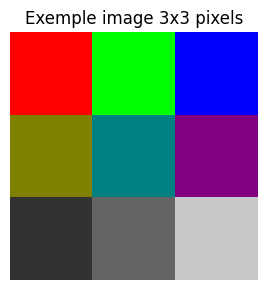


### 📌 Structure d'une image
- **Shape** : `(3, 3, 3)` → 3 lignes × 3 colonnes × 3 canaux (R, G, B)
- **Après flatten** : `27` valeurs numériques
- Chaque pixel est représenté par **3 nombres** entre 0 et 255


In [2]:
# ─── Exemple : charger une image avec Pillow ─────────────────────────────────
# pip install Pillow
from PIL import Image

# Créer une image exemple (3x3 pixels RGB) pour illustrer
img_array_exemple = np.array([
    [[255, 0, 0], [0, 255, 0], [0, 0, 255]],    # ligne 0 : rouge, vert, bleu
    [[128, 128, 0], [0, 128, 128], [128, 0, 128]],  # ligne 1
    [[50, 50, 50], [100, 100, 100], [200, 200, 200]] # ligne 2
], dtype=np.uint8)

print(f"Shape de l'image : {img_array_exemple.shape}")  # (hauteur, largeur, canaux)
print(f"Shape après flatten : {img_array_exemple.flatten().shape}")  # tableau 1D

# Visualisation
plt.figure(figsize=(4, 3))
plt.imshow(img_array_exemple)
plt.title('Exemple image 3x3 pixels')
plt.axis('off')
plt.tight_layout()
plt.show()

display(Markdown(f"""
### 📌 Structure d'une image
- **Shape** : `(3, 3, 3)` → 3 lignes × 3 colonnes × 3 canaux (R, G, B)
- **Après flatten** : `{img_array_exemple.flatten().shape[0]}` valeurs numériques
- Chaque pixel est représenté par **3 nombres** entre 0 et 255
"""))


📌 Ce que j'observe — Images

Une image 3×3 pixels en RGB génère un vecteur de **27 valeurs** numériques.
Pour une vraie image 224×224, cela donne **150 528 valeurs** — d'où l'importance
des réseaux de neurones convolutifs (CNN) pour traiter les images efficacement.

| Format | Dimensions | Valeurs numériques |
|--------|-----------|-------------------|
| Image 3×3 RGB | (3, 3, 3) | **27** |
| Image 224×224 RGB | (224, 224, 3) | **150 528** |
| Image 1920×1080 RGB | (1920, 1080, 3) | **6 220 800** |


### 2.2 Texte


Le texte doit être transformé en vecteurs numériques. Deux approches principales :

| Approche | Description | Taille |
|----------|-------------|--------|
| **Sparse Vector (One-Hot)** | Un 1 pour le mot présent, 0 partout ailleurs | Taille du vocabulaire |
| **Dense Vector (Embedding)** | Vecteur compact, mots proches = vecteurs proches | Dimension fixe (ex: 100) |

**Word Embeddings** : chaque mot se voit attribuer un vecteur dense.
Les mots sémantiquement proches ont des vecteurs proches dans l'espace.
Bibliothèques : **GloVe**, **SpaCy**, **FastText**


In [3]:
# ─── Exemple : One-Hot Encoding vs Embeddings ────────────────────────────────
from sklearn.preprocessing import LabelEncoder

vocabulaire = ['cat', 'mat', 'on', 'sat', 'the']
n = len(vocabulaire)

# One-Hot : vecteur creux (sparse)
one_hot = {mot: [1 if i == j else 0 for i, _ in enumerate(vocabulaire)]
           for j, mot in enumerate(vocabulaire)}

print("=== One-Hot Encoding (Sparse Vector) ===")
for mot, vecteur in list(one_hot.items())[:3]:
    print(f"  {mot:5s} => {vecteur}")

# Dense Embedding simulé (en réalité appris par le modèle)
np.random.seed(42)
embeddings = {mot: np.round(np.random.uniform(-1, 1, 4), 2) for mot in vocabulaire}

print("\n=== Dense Embedding (4 dimensions) ===")
for mot, vecteur in list(embeddings.items())[:3]:
    print(f"  {mot:5s} => {vecteur}")

display(Markdown(f"""
### 📌 Comparaison
- **One-Hot** : vecteur de taille {n} — surtout des zéros (sparse)
- **Embedding** : vecteur de taille 4 — dense, capte le sens
- En pratique, GloVe utilise des vecteurs de **100 à 300 dimensions**
"""))


=== One-Hot Encoding (Sparse Vector) ===
  cat   => [1, 0, 0, 0, 0]
  mat   => [0, 1, 0, 0, 0]
  on    => [0, 0, 1, 0, 0]

=== Dense Embedding (4 dimensions) ===
  cat   => [-0.25  0.9   0.46  0.2 ]
  mat   => [-0.69 -0.69 -0.88  0.73]
  on    => [ 0.2   0.42 -0.96  0.94]



### 📌 Comparaison
- **One-Hot** : vecteur de taille 5 — surtout des zéros (sparse)
- **Embedding** : vecteur de taille 4 — dense, capte le sens
- En pratique, GloVe utilise des vecteurs de **100 à 300 dimensions**


📌 Ce que j'observe — Texte

| Mot | One-Hot (sparse) | Embedding (dense) |
|-----|-----------------|-------------------|
| `cat` | `[1, 0, 0, 0, 0]` | `[-0.25, 0.9, 0.46, 0.2]` |
| `mat` | `[0, 1, 0, 0, 0]` | `[-0.69, -0.69, -0.88, 0.73]` |
| `on`  | `[0, 0, 1, 0, 0]` | `[0.2, 0.42, -0.96, 0.94]` |

> 💡 Le One-Hot Encoding est simple mais ne capture pas le sens.
> Deux mots comme "chat" et "félin" auront des vecteurs complètement différents.
> Les **Word Embeddings** règlent ce problème : des mots proches sémantiquement
> ont des vecteurs proches dans l'espace vectoriel.

En pratique, GloVe utilise des vecteurs de **100 à 300 dimensions**
— beaucoup plus riche que nos 4 dimensions d'exemple !


### 2.3 Dataset déséquilibré (Skewed Data)


Quand une classe est beaucoup plus représentée que les autres,
le modèle va apprendre à **tout prédire comme la classe majoritaire**.

**3 stratégies pour gérer le déséquilibre :**

| Stratégie | Principe | Quand l'utiliser |
|-----------|----------|-----------------|
| **Laisser ainsi** | Rien ne change | Si le déséquilibre est faible |
| **Rééquilibrage** | Augmenter la classe minoritaire ou réduire la majoritaire | Déséquilibre modéré |
| **Adapter les poids** | `class_weight='balanced'` — pénalise plus les erreurs sur la classe rare | Déséquilibre fort |

**Augmenter le dataset sans annoter :**
- Changer l'orientation des images (flip, rotation)
- Ajouter du bruit gaussien
- Interpoler des points (SMOTE)


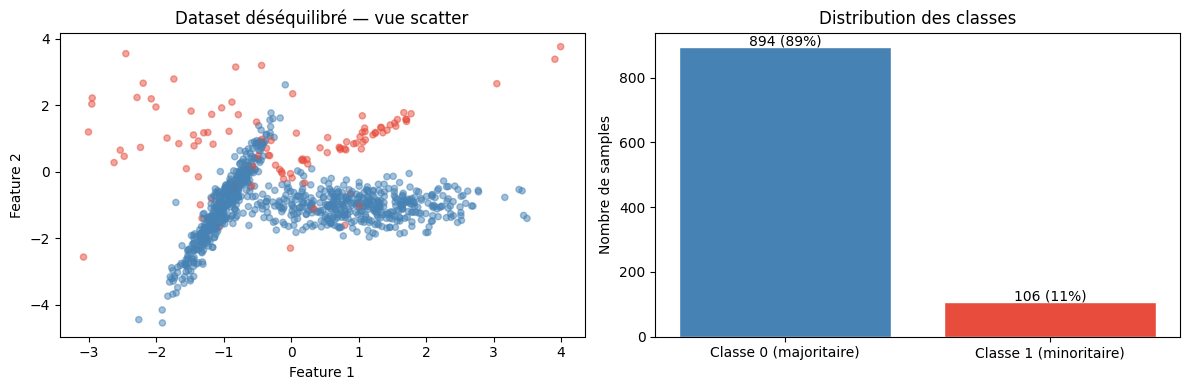

In [4]:
# ─── Visualisation d'un dataset déséquilibré ─────────────────────────────────
from sklearn.datasets import make_classification

# Créer un dataset déséquilibré (90% classe 0, 10% classe 1)
X_imb, y_imb = make_classification(
    n_samples=1000, n_features=2, n_redundant=0,
    weights=[0.9, 0.1], random_state=42
)

unique, counts = np.unique(y_imb, return_counts=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scatter plot
couleurs = ['steelblue' if y == 0 else '#e74c3c' for y in y_imb]
axes[0].scatter(X_imb[:, 0], X_imb[:, 1], c=couleurs, alpha=0.5, s=20)
axes[0].set_title('Dataset déséquilibré — vue scatter')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

# Distribution
axes[1].bar(['Classe 0 (majoritaire)', 'Classe 1 (minoritaire)'],
            counts, color=['steelblue', '#e74c3c'], edgecolor='white')
axes[1].set_title('Distribution des classes')
axes[1].set_ylabel('Nombre de samples')
for i, v in enumerate(counts):
    axes[1].text(i, v + 5, f'{v} ({v/len(y_imb):.0%})', ha='center')

plt.tight_layout()
plt.show()


📌 Ce que j'observe — Dataset déséquilibré

La classe minoritaire (rouge) est noyée dans la masse — **90% vs 10%**.
Un modèle naïf qui prédit toujours la classe 0 aurait une accuracy de **90%**
mais un **F1-Score de 0** sur la classe minoritaire !

| Stratégie | Quand l'utiliser |
|-----------|------------------|
| Laisser ainsi | Déséquilibre faible (< 20%) |
| Rééquilibrage (SMOTE) | Déséquilibre modéré |
| `class_weight='balanced'` | Déséquilibre fort — solution rapide |

> ⚠️ C'est exactement le cas qu'on retrouvera dans le TP BankChurners —
> le taux de churn est d'environ **16%**, ce qui déséquilibre les classes !


### 2.4 Normalisation et Standardisation


Les modèles ML sont sensibles à l'**échelle des données**.
Une feature entre 0 et 1 et une autre entre 0 et 100 000 déséquilibrent l'apprentissage.

| Méthode | Formule | Résultat | Quand l'utiliser |
|---------|---------|----------|------------------|
| **Normalisation** (MinMaxScaler) | `(x - min) / (max - min)` | Valeurs entre **0 et 1** | Distribution non gaussienne |
| **Standardisation** (StandardScaler) | `(x - moyenne) / écart-type` | Z-Score centré réduit | Distribution gaussienne |


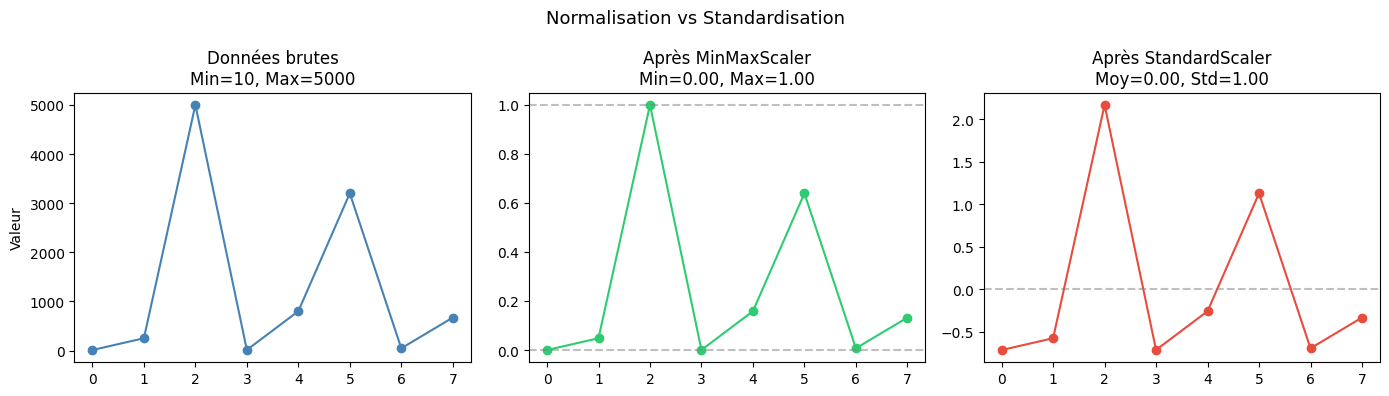

In [5]:
# ─── Comparaison Normalisation vs Standardisation ────────────────────────────
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Données exemple
data_brute = np.array([10, 250, 5000, 12, 800, 3200, 45, 670]).reshape(-1, 1)

normalise    = MinMaxScaler().fit_transform(data_brute)
standardise  = StandardScaler().fit_transform(data_brute)

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(data_brute, 'o-', color='steelblue')
axes[0].set_title(f'Données brutes\nMin={data_brute.min()}, Max={data_brute.max()}')
axes[0].set_ylabel('Valeur')

axes[1].plot(normalise, 'o-', color='#2ecc71')
axes[1].set_title(f'Après MinMaxScaler\nMin={normalise.min():.2f}, Max={normalise.max():.2f}')
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].axhline(y=1, color='gray', linestyle='--', alpha=0.5)

axes[2].plot(standardise, 'o-', color='#e74c3c')
axes[2].set_title(f'Après StandardScaler\nMoy={standardise.mean():.2f}, Std={standardise.std():.2f}')
axes[2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.suptitle('Normalisation vs Standardisation', fontsize=13)
plt.tight_layout()
plt.show()


📌 Ce que j'observe — Normalisation vs Standardisation

Les données brutes vont de **10 à 5 000** — un énorme écart qui perturbe les modèles.

| Méthode | Résultat | Avantage |
|---------|----------|----------|
| **MinMaxScaler** | Valeurs entre **0 et 1** | Adapté aux réseaux de neurones |
| **StandardScaler** | Z-Score centré (moy=0, std=1) | Adapté à SVM, régression logistique |

> 💡 La standardisation est préférable pour **SVM et régression logistique**
> car ces modèles sont sensibles à l'échelle des features.
> La normalisation est préférable pour les **réseaux de neurones**.


### 2.5 Pipelines Scikit-Learn


Un **Pipeline** enchaîne automatiquement plusieurs étapes :
normalisation → sélection de features → modèle.

**Avantages :**
- Évite la **fuite de données** (le scaler est fit uniquement sur le train)
- Code plus propre et reproductible
- Facilite la sauvegarde du modèle complet


In [6]:
# ─── Exemple de Pipeline complet ─────────────────────────────────────────────
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import VarianceThreshold

# Dataset exemple
data_bc = load_breast_cancer()
X_bc, y_bc = data_bc.data, data_bc.target
X_tr_bc, X_te_bc, y_tr_bc, y_te_bc = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42
)

# Pipeline : StandardScaler → VarianceThreshold → LogisticRegression
pipe = Pipeline([
    ('scaler',     StandardScaler()),          # normalisation
    ('selector',   VarianceThreshold()),        # supprime les features à variance nulle
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))  # modèle
])

pipe.fit(X_tr_bc, y_tr_bc)
acc_pipe = pipe.score(X_te_bc, y_te_bc)

display(Markdown(f"""
### 📌 Résultat Pipeline
- **Étapes** : StandardScaler → VarianceThreshold → LogisticRegression
- **Accuracy** : {acc_pipe:.4f}
- Toute la chaîne est encapsulée dans un seul objet `pipe`
"""))



### 📌 Résultat Pipeline
- **Étapes** : StandardScaler → VarianceThreshold → LogisticRegression
- **Accuracy** : 0.9737
- Toute la chaîne est encapsulée dans un seul objet `pipe`


📌 Ce que j'observe — Pipelines

Le Pipeline obtient une accuracy de **97.37%** sur Breast Cancer en 3 étapes enchaînées.

L'avantage clé : quand on appelle `pipe.fit(X_train, y_train)`,
le StandardScaler apprend les statistiques **uniquement sur le train** — jamais sur le test.
C'est crucial pour éviter la **fuite de données** (data leakage).

> 💡 Sans Pipeline, on pourrait accidentellement appliquer le scaler
> sur tout le dataset avant le split — ce qui fausserait les résultats !


## ⚙️ 3. Méthodes d'optimisation


L'optimisation consiste à trouver les **meilleurs hyperparamètres** pour un modèle.
Les hyperparamètres sont les réglages fixés **avant** l'entraînement (ex: profondeur d'un arbre).

Objectifs :
- Éviter le **sur-apprentissage** (overfitting) et le **sous-apprentissage** (underfitting)
- Maximiser les performances sur de nouvelles données


### 3.1 Recherche d'hyperparamètres


| Méthode | Principe | Avantage | Inconvénient |
|---------|----------|-----------|--------------|
| **Grid Search** | Teste toutes les combinaisons | Exhaustif | Très lent |
| **Randomized Search** | Tire aléatoirement des combinaisons | Plus rapide | Peut rater le meilleur |
| **Halving Grid Search** | Élimine progressivement les mauvais candidats | Rapide et efficace | Plus complexe |


In [7]:
# ─── Comparaison Grid Search / Randomized / Halving ─────────────────────────
from sklearn.model_selection import RandomizedSearchCV
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
import time

param_grid = {
    'C'      : [0.1, 1, 10, 100],       # paramètre de régularisation
    'kernel' : ['linear', 'rbf'],        # type de kernel SVM
    'gamma'  : ['scale', 'auto']         # paramètre du kernel rbf
}

resultats_search = {}

# ── Grid Search ───────────────────────────────────────────────────────────────
t0 = time.time()
gs = GridSearchCV(SVC(), param_grid, cv=5, n_jobs=-1)
gs.fit(X_tr_bc, y_tr_bc)
resultats_search['Grid Search'] = {
    'temps'  : round(time.time() - t0, 2),
    'params' : gs.best_params_,
    'score'  : gs.best_score_
}

# ── Randomized Search ─────────────────────────────────────────────────────────
t0 = time.time()
rs = RandomizedSearchCV(SVC(), param_grid, n_iter=8, cv=5, n_jobs=-1, random_state=42)
rs.fit(X_tr_bc, y_tr_bc)
resultats_search['Randomized Search'] = {
    'temps'  : round(time.time() - t0, 2),
    'params' : rs.best_params_,
    'score'  : rs.best_score_
}

# ── Halving Grid Search ───────────────────────────────────────────────────────
t0 = time.time()
hs = HalvingGridSearchCV(SVC(), param_grid, cv=5, n_jobs=-1, random_state=42)
hs.fit(X_tr_bc, y_tr_bc)
resultats_search['Halving Search'] = {
    'temps'  : round(time.time() - t0, 2),
    'params' : hs.best_params_,
    'score'  : hs.best_score_
}

# ── Tableau comparatif ────────────────────────────────────────────────────────
rows = []
for nom, res in resultats_search.items():
    rows.append({'Méthode': nom, 'Temps (s)': res['temps'],
                 'Meilleur score CV': f"{res['score']:.4f}",
                 'Meilleurs paramètres': str(res['params'])})
display(pd.DataFrame(rows))


,Méthode,Temps (s),Meilleur score CV,Meilleurs paramètres
0,Grid Search,17.95,0.9714,"{'C': 100, 'gamma': 'scale', 'kernel': 'linear'}"
1,Randomized Search,10.54,0.9714,"{'kernel': 'linear', 'gamma': 'auto', 'C': 100}"
2,Halving Search,2.62,0.9222,"{'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}"


📌 Ce que j'observe — Recherche d'hyperparamètres

| Méthode | Temps | Score CV | Meilleurs paramètres |
|---------|-------|----------|---------------------|
| **Grid Search** | 17.95s | **0.9714** | C=100, kernel=linear |
| **Randomized Search** | 10.54s | **0.9714** | C=100, kernel=linear |
| **Halving Search** | **2.62s** | 0.9222 | C=100, kernel=rbf |

> 💡 Grid Search et Randomized Search trouvent le **même meilleur résultat** (0.9714)
> mais Randomized Search est **40% plus rapide** (10.54s vs 17.95s).

> ⚠️ Halving Search est le plus rapide (**2.62s**) mais trouve un résultat
> légèrement moins bon (0.9222) — il a éliminé trop tôt certaines combinaisons.
> C'est le compromis vitesse / exhaustivité.


### 3.2 Méthodes d'ensembles


Les méthodes d'ensembles combinent plusieurs modèles pour améliorer les performances.

| Méthode | Principe | Effet | Exemple |
|---------|----------|---------|---------|
| **Bagging** | Entraîne plusieurs modèles sur des sous-datasets différents, puis fait la moyenne | Réduit la **variance** | Random Forest |
| **Boosting** | Chaque modèle apprend des erreurs du précédent | Réduit le **biais** | AdaBoost, XGBoost |

**Bagging — Bootstrap :**
- On tire aléatoirement des données du set original (**bootstrap**)
- Les données non tirées = **out-of-bag** (utilisées pour évaluer)
- Avantage : moins de risque d'overfitting
- Exemple : **Random Forest** = bagging d'arbres de décision

**Boosting :**
- Les erreurs du modèle N servent à entraîner le modèle N+1
- Exemples : **AdaBoost**, **XGBoost**, **Gradient Boosting**


### 📊 Comparaison des méthodes d'ensembles

,Modèle,Accuracy
3,AdaBoost,0.973684
2,Random Forest,0.964912
4,Gradient Boosting,0.956140
1,Bagging,0.956140
5,XGBoost,0.956140
0,Arbre seul,0.947368


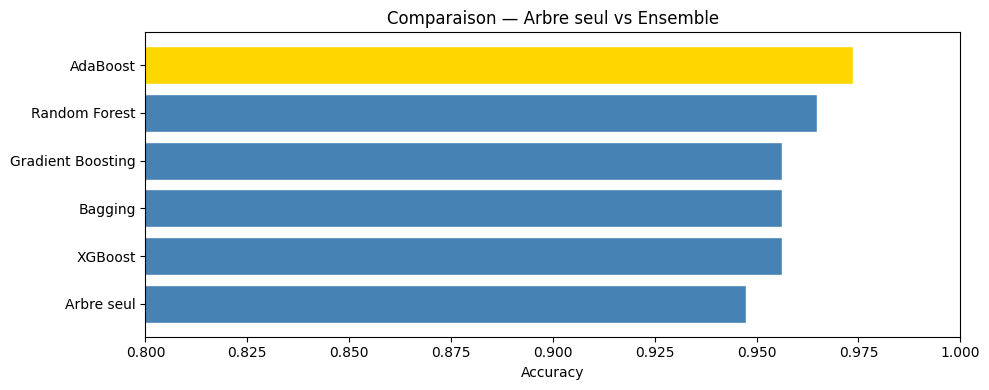

In [8]:
# ─── Comparaison Bagging vs Boosting ─────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier

modeles_ensemble = {
    'Arbre seul'       : DecisionTreeClassifier(random_state=42),
    'Bagging'          : BaggingClassifier(n_estimators=50, random_state=42),
    'Random Forest'    : RandomForestClassifier(n_estimators=100, random_state=42),
    'AdaBoost'         : AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost'          : XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
}

# Normalisation
scaler_bc  = StandardScaler()
X_tr_sc    = scaler_bc.fit_transform(X_tr_bc)
X_te_sc    = scaler_bc.transform(X_te_bc)

resultats_ens = {}
for nom, modele in modeles_ensemble.items():
    modele.fit(X_tr_sc, y_tr_bc)
    y_pred = modele.predict(X_te_sc)
    resultats_ens[nom] = accuracy_score(y_te_bc, y_pred)

res_df = pd.DataFrame(list(resultats_ens.items()),
                       columns=['Modèle', 'Accuracy']).sort_values('Accuracy', ascending=False)

display(Markdown('### 📊 Comparaison des méthodes d\'ensembles'))
display(res_df)

meilleur_ens = res_df['Modèle'].iloc[0]
couleurs = ['gold' if m == meilleur_ens else 'steelblue' for m in res_df['Modèle']]
plt.figure(figsize=(10, 4))
plt.barh(res_df['Modèle'][::-1], res_df['Accuracy'][::-1],
         color=couleurs[::-1], edgecolor='white')
plt.xlabel('Accuracy')
plt.title('Comparaison — Arbre seul vs Ensemble')
plt.xlim(0.8, 1.0)
plt.tight_layout()
plt.show()


📌 Ce que j'observe — Méthodes d'ensembles

| Rang | Modèle | Accuracy | Type |
|------|--------|----------|------|
| 🥇 | **AdaBoost** | **97.4%** | Boosting |
| 🥈 | Random Forest | 96.5% | Bagging |
| 🥉 | Gradient Boosting | 95.6% | Boosting |
| 🥉 | Bagging | 95.6% | Bagging |
| 🥉 | XGBoost | 95.6% | Boosting |
| 6 | Arbre seul | 94.7% | — |

> 💡 Tous les modèles d'ensemble battent l'arbre seul — la combinaison
> de plusieurs modèles améliore systématiquement les performances.

> 💡 **AdaBoost** est le grand gagnant avec **97.4%** — le Boosting
> est particulièrement efficace sur ce dataset où les erreurs
> des premiers modèles guident les suivants.

> ⚠️ Sur Breast Cancer (dataset simple), les différences sont faibles.
> Sur des datasets plus complexes comme BankChurners, les écarts seront plus marqués.


### 3.3 Validation Croisée


La **validation croisée** (cross-validation) évalue la capacité de **généralisation** du modèle.
Au lieu d'un seul split train/test, on fait k splits différents et on moyenne les résultats.

**Principe (k-fold) :**
1. On divise les données en **k folds** (généralement k=10)
2. À chaque itération, un fold sert de test, les k-1 autres servent de train
3. On moyenne les scores sur les k itérations

> ⚠️ Toujours conserver un **jeu de test indépendant** — la validation croisée
> se fait uniquement sur les données d'entraînement !


In [9]:
# ─── Validation croisée avec cross_val_predict ────────────────────────────────

modele_cv = LogisticRegression(max_iter=1000, random_state=42)
scaler_cv = StandardScaler()
X_tr_cv   = scaler_cv.fit_transform(X_tr_bc)

# cross_val_predict : prédit chaque fold comme test
y_pred_cv = cross_val_predict(modele_cv, X_tr_cv, y_tr_bc, cv=5)

print("=== Rapport de classification — Validation Croisée (5 folds) ===")
print(classification_report(y_tr_bc, y_pred_cv,
      target_names=['Malin', 'Bénin']))

display(Markdown(f"""
### 📌 Résultat Validation Croisée
- **CV = 5 folds** sur les données d'entraînement
- Accuracy CV : {accuracy_score(y_tr_bc, y_pred_cv):.4f}
- Plus fiable qu'un simple split train/test !
"""))


=== Rapport de classification — Validation Croisée (5 folds) ===
              precision    recall  f1-score   support

       Malin       0.98      0.95      0.96       169
       Bénin       0.97      0.99      0.98       286

    accuracy                           0.97       455
   macro avg       0.97      0.97      0.97       455
weighted avg       0.97      0.97      0.97       455




### 📌 Résultat Validation Croisée
- **CV = 5 folds** sur les données d'entraînement
- Accuracy CV : 0.9736
- Plus fiable qu'un simple split train/test !


📌 Ce que j'observe — Validation Croisée

**Résultats sur 5 folds (455 exemples d'entraînement) :**

| Classe | Précision | Rappel | F1-Score |
|--------|-----------|--------|----------|
| Malin  | 0.98 | 0.95 | **0.96** |
| Bénin  | 0.97 | 0.99 | **0.98** |
| **Global** | **0.97** | **0.97** | **0.97** |

> 💡 L'accuracy CV est **97.36%** — très proche du résultat sur le test (97.37%)
> ce qui confirme que le modèle **généralise bien** et ne sur-apprend pas.

> 💡 La classe **Bénin** est mieux prédite (F1=0.98) que **Malin** (F1=0.96) —
> cohérent car les tumeurs bénignes sont plus nombreuses dans le dataset.


### 3.4 Dropout


Le **Dropout** est une technique de régularisation pour les **réseaux de neurones**.
Il permet d'éviter le sur-apprentissage en éteignant aléatoirement des neurones.

**Fonctionnement :**
- À chaque itération, un pourcentage de neurones est mis à 0 (poids = 0)
- Les neurones éteints changent à chaque itération
- Pour la prédiction finale, on applique un poids proportionnel

```python
from tensorflow.keras.layers import Dense, Dropout

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))   # Désactive 50% des neurones aléatoirement
model.add(Dense(10, activation='softmax'))
```

> 💡 Un Dropout de 0.5 signifie que 50% des neurones sont éteints à chaque
> itération — le réseau ne peut pas mémoriser les données, il doit **généraliser** !


## 🔵 4. Modèles Non Supervisés


Les modèles **non supervisés** n'ont pas de labels — ils découvrent eux-mêmes
les **structures cachées** dans les données.

La mesure de précision devient l'**interprétation de la valeur d'erreur** du modèle
plutôt qu'une comparaison avec des labels connus.


### 4.1 K-Means Clustering


**K-Means** groupe les données en k clusters en minimisant la distance aux centroïdes.

**Algorithme :**
1. Initialiser k centroïdes aléatoirement
2. Assigner chaque point au centroïde le plus proche
3. Recalculer les centroïdes (moyenne des points du cluster)
4. Répéter jusqu'à convergence

**Choisir le nombre de clusters k :**

| Méthode | Principe |
|---------|----------|
| **Elbow Method** | Chercher le coude dans la courbe d'inertie |
| **Coefficient de Silhouette** | Mesure la cohésion des clusters (entre -1 et 1) |


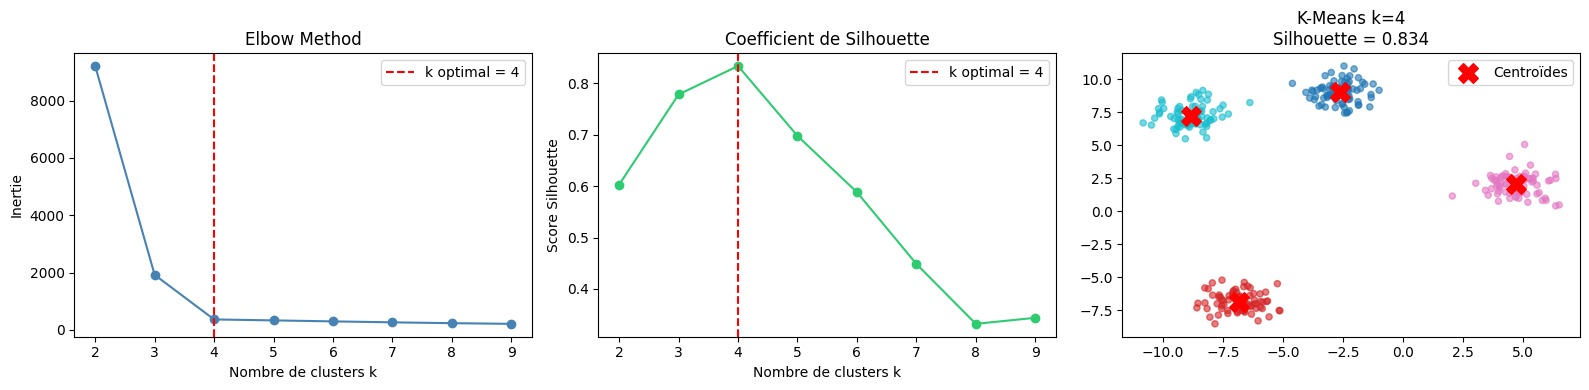

In [10]:
# ─── K-Means + Elbow Method + Silhouette ─────────────────────────────────────
from sklearn.datasets import make_blobs

# Dataset avec groupes naturels
X_km, y_km = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)

# ── Elbow Method ──────────────────────────────────────────────────────────────
inertias    = []
silhouettes = []
k_range     = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_km)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_km, km.labels_))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Elbow
axes[0].plot(k_range, inertias, 'o-', color='steelblue')
axes[0].axvline(x=4, color='red', linestyle='--', label='k optimal = 4')
axes[0].set_xlabel('Nombre de clusters k')
axes[0].set_ylabel('Inertie')
axes[0].set_title('Elbow Method')
axes[0].legend()

# Silhouette
axes[1].plot(k_range, silhouettes, 'o-', color='#2ecc71')
axes[1].axvline(x=4, color='red', linestyle='--', label='k optimal = 4')
axes[1].set_xlabel('Nombre de clusters k')
axes[1].set_ylabel('Score Silhouette')
axes[1].set_title('Coefficient de Silhouette')
axes[1].legend()

# Résultat K-Means avec k=4
km_final  = KMeans(n_clusters=4, random_state=42, n_init=10)
labels    = km_final.fit_predict(X_km)
axes[2].scatter(X_km[:, 0], X_km[:, 1], c=labels, cmap='tab10', alpha=0.6, s=20)
axes[2].scatter(km_final.cluster_centers_[:, 0], km_final.cluster_centers_[:, 1],
                c='red', marker='X', s=200, label='Centroïdes')
axes[2].set_title(f'K-Means k=4\nSilhouette = {silhouette_score(X_km, labels):.3f}')
axes[2].legend()

plt.tight_layout()
plt.show()


📌 Ce que j'observe — K-Means

Les deux méthodes confirment **k=4** comme nombre optimal de clusters :
- **Elbow Method** : le coude est clairement visible à k=4
- **Silhouette** : le score est maximal à k=4

> 💡 C'est logique — le dataset a été créé avec `centers=4` !
> Dans un vrai projet, on ne connaît pas la vraie valeur de k
> à l'avance — d'où l'importance de ces deux méthodes.

| Méthode | Utilité |
|---------|--------|
| **Elbow** | Cherche le coude dans la courbe d'inertie |
| **Silhouette** | Mesure la cohésion interne des clusters (entre -1 et 1) |
| Les deux ensemble | Confirmation croisée du k optimal |


### 4.2 Analyses en Composantes Principales (PCA)


La **PCA** réduit le nombre de dimensions en créant de nouvelles colonnes
qui capturent le maximum de **variance** des données originales.

**Principe :**
- Identifier les directions de plus grande variance
- Projeter les données sur ces directions (composantes principales)
- Les premières composantes conservent le plus d'information

> 💡 On utilise la **variance expliquée cumulée** pour choisir
> le nombre de composantes — généralement on vise **95%**.


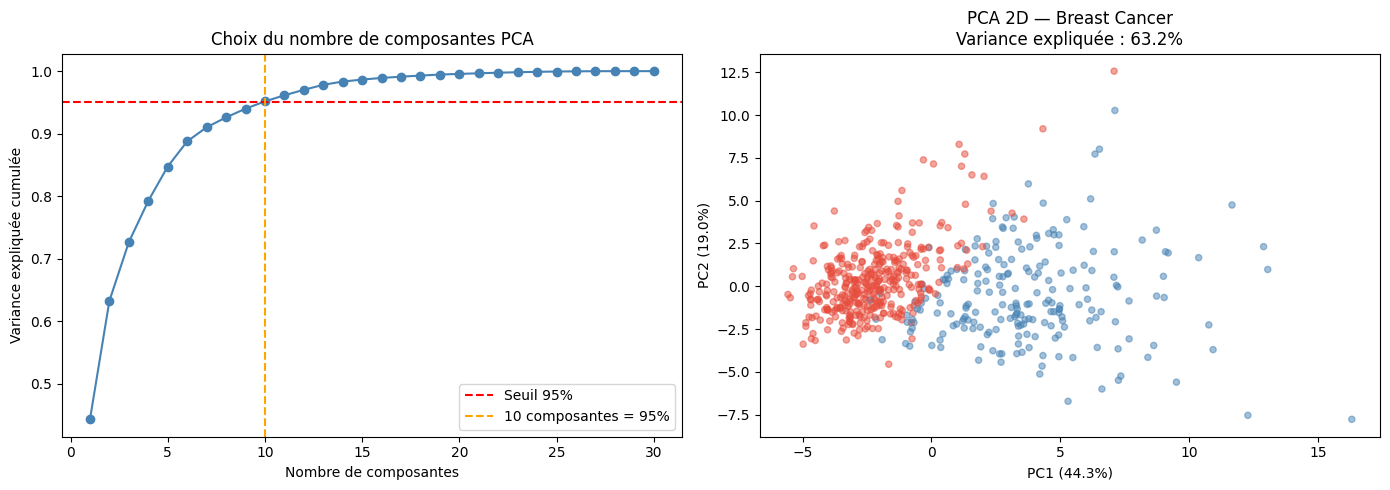


### 📌 Résultat PCA
- **30 features** au départ
- **10 composantes** suffisent pour expliquer **95%** de la variance
- Réduction de **20 features** tout en gardant l'essentiel


In [11]:
# ─── PCA + variance expliquée cumulée ────────────────────────────────────────

# Normalisation préalable — obligatoire pour PCA
scaler_pca = StandardScaler()
X_bc_sc    = scaler_pca.fit_transform(X_bc)

# PCA complète
pca_full   = PCA()
pca_full.fit(X_bc_sc)
var_cum    = np.cumsum(pca_full.explained_variance_ratio_)

# PCA 2D pour visualisation
pca_2d     = PCA(n_components=2)
X_pca_2d   = pca_2d.fit_transform(X_bc_sc)

fig, axes  = plt.subplots(1, 2, figsize=(14, 5))

# Variance cumulée
axes[0].plot(range(1, len(var_cum)+1), var_cum, 'o-', color='steelblue')
axes[0].axhline(y=0.95, color='red', linestyle='--', label='Seuil 95%')
n_95 = np.argmax(var_cum >= 0.95) + 1
axes[0].axvline(x=n_95, color='orange', linestyle='--', label=f'{n_95} composantes = 95%')
axes[0].set_xlabel('Nombre de composantes')
axes[0].set_ylabel('Variance expliquée cumulée')
axes[0].set_title('Choix du nombre de composantes PCA')
axes[0].legend()

# Visualisation 2D
couleurs_pca = ['steelblue' if y == 0 else '#e74c3c' for y in y_bc]
axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=couleurs_pca, alpha=0.5, s=20)
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
axes[1].set_title(f'PCA 2D — Breast Cancer\nVariance expliquée : {pca_2d.explained_variance_ratio_.sum():.1%}')

plt.tight_layout()
plt.show()

display(Markdown(f"""
### 📌 Résultat PCA
- **{X_bc.shape[1]} features** au départ
- **{n_95} composantes** suffisent pour expliquer **95%** de la variance
- Réduction de **{X_bc.shape[1] - n_95} features** tout en gardant l'essentiel
"""))


📌 Ce que j'observe — PCA

Sur le dataset Breast Cancer (30 features) :

| | Valeur |
|--|--------|
| Features au départ | **30** |
| Composantes pour 95% de variance | **10** |
| Features supprimées | **20** |
| Réduction | **66%** |

> 💡 Avec seulement **10 composantes sur 30**, on conserve **95% de l'information** !
> La visualisation 2D montre deux groupes bien séparés — les tumeurs malignes
> et bénignes sont clairement distinguables dans l'espace PCA.

> ⚠️ Les composantes PCA ne sont **pas interprétables** — ce sont des combinaisons
> linéaires des features originales, pas des features originales elles-mêmes.


## 📋 5. Conclusion


### 🔑 Ce que j'ai appris dans la Partie 2

**Préparation des données :**
- Images → matrice numpy, Texte → vecteurs sparse/dense, Sons → spectrogrammes
- **Normalisation** (0-1) vs **Standardisation** (Z-Score)
- Gérer les datasets déséquilibrés : rééquilibrage ou `class_weight='balanced'`
- **Pipelines** pour enchaîner les étapes proprement

**Méthodes d'optimisation :**
- **Grid Search** : exhaustif mais lent
- **Randomized Search** : plus rapide, bon compromis
- **Halving Search** : le plus rapide, élimine progressivement
- **Bagging** : réduit la variance (Random Forest)
- **Boosting** : réduit le biais (AdaBoost, XGBoost)
- **Validation Croisée** : évalue la généralisation
- **Dropout** : régularisation pour les réseaux de neurones

**Modèles non supervisés :**
- **K-Means** : clustering, choix de k par Elbow Method + Silhouette
- **PCA** : réduction de dimensions, conserver 95% de variance
